In [1]:
import os
import random
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
def seed_everything(seed=42):
    import os
    import random
    import numpy as np
    import tensorflow as tf

    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["TF_NUM_INTRAOP_THREADS"] = "1"
    os.environ["TF_NUM_INTEROP_THREADS"] = "1"

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    tf.config.threading.set_intra_op_parallelism_threads(1)
    tf.config.threading.set_inter_op_parallelism_threads(1)

    tf.config.optimizer.set_jit(False)


seed_everything(42)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [4]:
from pathlib import Path

dataset_name = "youtube_static.csv"
data_file = Path.cwd().parents[1] / "data" / "filtered" / dataset_name

df = pd.read_csv(data_file, parse_dates=["DATE"], index_col="DATE")
print("Loaded:", data_file)

Loaded: C:\Users\EJ17UF\OneDrive - Aalborg Universitet\Desktop\ms\data\filtered\youtube_static.csv


In [5]:
target = 'mac_dl_brate'

input_steps = 96
prediction_horizon = 96

train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.1)

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print("Training Data:", len(train_df))
print("Validation Data:", len(val_df))
print("Test Data:", len(test_df))

# use only the target column
scaler_target = MinMaxScaler()

train_scaled = scaler_target.fit_transform(train_df[[target]])   # shape: (N, 1)
val_scaled = scaler_target.transform(val_df[[target]])
test_scaled = scaler_target.transform(test_df[[target]])


def create_sequences_patchtst_univariate(data, input_steps, prediction_horizon, index):
    X, y, dates = [], [], []

    for i in range(len(data) - input_steps - prediction_horizon + 1):
        X_seq = data[i:i + input_steps, :]   # (input_steps, 1)
        y_seq = data[i + input_steps:i + input_steps + prediction_horizon, :]  # (pred_len, 1)
        date_seq = index[i + input_steps:i + input_steps + prediction_horizon]

        X.append(X_seq)
        y.append(y_seq)
        dates.append(date_seq)

    return np.array(X), np.array(y), dates

X_train_uni, y_train_uni, train_dates = create_sequences_patchtst_univariate(
    train_scaled, input_steps, prediction_horizon, train_df.index
)

X_val_uni, y_val_uni, val_dates = create_sequences_patchtst_univariate(
    val_scaled, input_steps, prediction_horizon, val_df.index
)

X_test_uni, y_test_uni, test_dates = create_sequences_patchtst_univariate(
    test_scaled, input_steps, prediction_horizon, test_df.index
)

print("X_train_uni:", X_train_uni.shape)
print("y_train_uni:", y_train_uni.shape)
print("X_val_uni:", X_val_uni.shape)
print("y_val_uni:", y_val_uni.shape)
print("X_test_uni:", X_test_uni.shape)
print("y_test_uni:", y_test_uni.shape)

Training Data: 22970
Validation Data: 3281
Test Data: 6564


X_train_uni: (22779, 96, 1)
y_train_uni: (22779, 96, 1)
X_val_uni: (3090, 96, 1)
y_val_uni: (3090, 96, 1)
X_test_uni: (6373, 96, 1)
y_test_uni: (6373, 96, 1)


In [6]:
# RevIN
class RevINNormalize(layers.Layer):
    def __init__(self, num_features, eps=1e-5, affine=True, subtract_last=False, name="revin_norm"):
        super().__init__(name=name)
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        self.subtract_last = subtract_last

    def build(self, input_shape):
        if self.affine:
            self.affine_weight = self.add_weight(
                name="affine_weight",
                shape=(1, 1, self.num_features),
                initializer="ones",
                trainable=True
            )
            self.affine_bias = self.add_weight(
                name="affine_bias",
                shape=(1, 1, self.num_features),
                initializer="zeros",
                trainable=True
            )

    def call(self, x):
        # x: (B, L, C)
        if self.subtract_last:
            ref = x[:, -1:, :]
        else:
            ref = tf.reduce_mean(x, axis=1, keepdims=True)

        var = tf.reduce_mean(tf.square(x - ref), axis=1, keepdims=True)
        stdev = tf.sqrt(var + self.eps)

        x_norm = (x - ref) / stdev

        if self.affine:
            x_norm = x_norm * self.affine_weight + self.affine_bias

        return x_norm, ref, stdev


class RevINDenormalize(layers.Layer):
    def __init__(self, eps=1e-5, affine=True, name="revin_denorm"):
        super().__init__(name=name)
        self.eps = eps
        self.affine = affine

    def call(self, inputs, affine_weight=None, affine_bias=None):
        x, ref, stdev = inputs  # x: (B, pred_len, C)

        if self.affine and affine_weight is not None and affine_bias is not None:
            x = x - affine_bias
            x = x / (affine_weight + self.eps * self.eps)

        x = x * stdev
        x = x + ref
        return x


# Series decomposition
class MovingAverage(layers.Layer):
    def __init__(self, kernel_size, name="moving_avg"):
        super().__init__(name=name)
        self.kernel_size = kernel_size
        self.pool = layers.AveragePooling1D(pool_size=kernel_size, strides=1, padding="valid")

    def call(self, x):
        # x: (B, L, C)
        pad_left = (self.kernel_size - 1) // 2
        pad_right = self.kernel_size - 1 - pad_left

        front = tf.repeat(x[:, 0:1, :], repeats=pad_left, axis=1)
        end = tf.repeat(x[:, -1:, :], repeats=pad_right, axis=1)
        x_pad = tf.concat([front, x, end], axis=1)
        return self.pool(x_pad)


class SeriesDecomposition(layers.Layer):
    def __init__(self, kernel_size, name="series_decomp"):
        super().__init__(name=name)
        self.moving_avg = MovingAverage(kernel_size)

    def call(self, x):
        trend = self.moving_avg(x)
        residual = x - trend
        return residual, trend


# Patch embedding with end padding
class PatchEmbedding(layers.Layer):
    def __init__(self, patch_len, stride, d_model, padding_patch='end', name="patch_embedding"):
        super().__init__(name=name)
        self.patch_len = patch_len
        self.stride = stride
        self.padding_patch = padding_patch
        self.proj = layers.Dense(d_model)

    def call(self, x):
        # x: (B*C, L)
        seq_len = tf.shape(x)[1]

        if self.padding_patch == 'end':
            remainder = (seq_len - self.patch_len) % self.stride
            pad_len = tf.where(tf.equal(remainder, 0), 0, self.stride - remainder)
            x = tf.pad(x, [[0, 0], [0, pad_len]])
        elif self.padding_patch in [None, 'none']:
            pass
        else:
            raise ValueError("padding_patch must be 'end' or None")

        patches = tf.signal.frame(
            x,
            frame_length=self.patch_len,
            frame_step=self.stride,
            axis=1
        )  # (B*C, num_patches, patch_len)

        return self.proj(patches)

# Positional encoding
class PositionalEncoding(layers.Layer):
    def __init__(self, pe='zeros', learn_pe=True, name="positional_encoding"):
        super().__init__(name=name)
        self.pe = pe
        self.learn_pe = learn_pe

    def build(self, input_shape):
        _, q_len, d_model = input_shape

        if self.pe == 'zeros':
            init = tf.zeros_initializer()
        elif self.pe == 'normal':
            init = tf.random_normal_initializer(stddev=0.02)
        else:
            # fallback simplified option
            init = tf.random_normal_initializer(stddev=0.02)

        self.pos_emb = self.add_weight(
            name="pos_emb",
            shape=(1, q_len, d_model),
            initializer=init,
            trainable=self.learn_pe
        )

    def call(self, x):
        return x + self.pos_emb


# Normalization helper
class NormLayer(layers.Layer):
    def __init__(self, norm_type='LayerNorm', epsilon=1e-6, name=None):
        super().__init__(name=name)
        self.norm_type = norm_type
        self.epsilon = epsilon

        if norm_type == 'BatchNorm':
            self.bn = layers.BatchNormalization(epsilon=epsilon)
        else:
            self.ln = layers.LayerNormalization(epsilon=epsilon)

    def call(self, x, training=False):
        # x: (B, T, D)
        if self.norm_type == 'BatchNorm':
            # BatchNorm over feature dim; works directly on (B,T,D)
            return self.bn(x, training=training)
        else:
            return self.ln(x)


# Transformer encoder block
class TransformerEncoder(layers.Layer):
    def __init__(
        self,
        d_model,
        num_heads,
        dff,
        dropout=0.2,
        attn_dropout=0.0,
        pre_norm=False,
        norm_type='LayerNorm',
        name=None
    ):
        super().__init__(name=name)
        self.pre_norm = pre_norm

        self.norm1 = NormLayer(norm_type=norm_type, name=f"{name}_norm1" if name else None)
        self.attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=attn_dropout
        )
        self.dropout1 = layers.Dropout(dropout)

        self.norm2 = NormLayer(norm_type=norm_type, name=f"{name}_norm2" if name else None)
        self.ffn = tf.keras.Sequential([
            layers.Dense(dff, activation='gelu'),
            layers.Dropout(dropout),
            layers.Dense(d_model)
        ])
        self.dropout2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        if self.pre_norm:
            # PreNorm
            x_norm = self.norm1(x, training=training)
            attn_out = self.attn(x_norm, x_norm, training=training)
            x = x + self.dropout1(attn_out, training=training)

            x_norm = self.norm2(x, training=training)
            ffn_out = self.ffn(x_norm, training=training)
            x = x + self.dropout2(ffn_out, training=training)
        else:
            # PostNorm
            attn_out = self.attn(x, x, training=training)
            x = x + self.dropout1(attn_out, training=training)
            x = self.norm1(x, training=training)

            ffn_out = self.ffn(x, training=training)
            x = x + self.dropout2(ffn_out, training=training)
            x = self.norm2(x, training=training)

        return x



# PatchTST backbone
class PatchTSTBackbone(layers.Layer):
    def __init__(
        self,
        seq_len,
        pred_len,
        n_channels,
        patch_len=16,
        stride=8,
        d_model=128,
        num_heads=8,
        num_layers=3,
        dff=256,
        dropout=0.2,
        attn_dropout=0.0,
        fc_dropout=0.2,
        head_dropout=0.0,
        padding_patch='end',
        pre_norm=False,
        norm_type='LayerNorm',
        pe='zeros',
        learn_pe=True,
        individual=False,
        name="patchtst_backbone"
    ):
        super().__init__(name=name)

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.n_channels = n_channels
        self.individual = individual

        self.patch_embed = PatchEmbedding(
            patch_len=patch_len,
            stride=stride,
            d_model=d_model,
            padding_patch=padding_patch
        )

        self.pos_enc = PositionalEncoding(pe=pe, learn_pe=learn_pe)

        self.encoders = [
            TransformerEncoder(
                d_model=d_model,
                num_heads=num_heads,
                dff=dff,
                dropout=dropout,
                attn_dropout=attn_dropout,
                pre_norm=pre_norm,
                norm_type=norm_type,
                name=f"encoder_{i}"
            )
            for i in range(num_layers)
        ]

        self.flatten = layers.Flatten()
        self.fc_dropout = layers.Dropout(fc_dropout)
        self.head_dropout = layers.Dropout(head_dropout)

        # shared head (default official-style when individual=False)
        if not self.individual:
            self.shared_head = layers.Dense(pred_len)

        # optional individual heads (closer to optional repo behavior)
        else:
            self.individual_heads = [layers.Dense(pred_len) for _ in range(n_channels)]

    def call(self, x, training=False):
        # x: (B, L, C)

        # channel-independence:
        # (B, L, C) -> (B, C, L) -> (B*C, L)
        x_bc_l = tf.transpose(x, perm=[0, 2, 1])               # (B, C, L)
        batch_size = tf.shape(x_bc_l)[0]
        x_merged = tf.reshape(x_bc_l, (-1, self.seq_len))      # (B*C, L)

        x_merged = self.patch_embed(x_merged)                   # (B*C, Np, d_model)
        x_merged = self.pos_enc(x_merged)

        for enc in self.encoders:
            x_merged = enc(x_merged, training=training)

        x_merged = self.flatten(x_merged)
        x_merged = self.fc_dropout(x_merged, training=training)

        if not self.individual:
            x_merged = self.shared_head(x_merged)              # (B*C, pred_len)
        else:
            # restore first, then apply separate head per channel
            x_tmp = tf.reshape(x_merged, (batch_size, self.n_channels, -1))
            outs = []
            for c in range(self.n_channels):
                xc = x_tmp[:, c, :]
                outs.append(self.individual_heads[c](xc))
            x_merged = tf.stack(outs, axis=1)                  # (B, C, pred_len)
            x_merged = self.head_dropout(x_merged, training=training)
            return tf.transpose(x_merged, perm=[0, 2, 1])      # (B, pred_len, C)

        x_merged = self.head_dropout(x_merged, training=training)
        x_merged = tf.reshape(x_merged, (batch_size, self.n_channels, self.pred_len))
        return tf.transpose(x_merged, perm=[0, 2, 1])          # (B, pred_len, C)


# Full PatchTST model
def build_patchtst_multivariate(
    seq_len,
    pred_len,
    n_channels,
    patch_len=16,
    stride=8,
    d_model=512,
    num_heads=8,
    num_layers=3,
    dff=2048,
    dropout=0.2,
    attn_dropout=0.0,
    fc_dropout=0.2,
    head_dropout=0.0,
    padding_patch='end',
    revin=True,
    affine=True,
    subtract_last=False,
    decomposition=False,
    kernel_size=25,
    pre_norm=False,
    norm_type='BatchNorm',  
    pe='zeros',
    learn_pe=True,
    individual=False
):

    assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

    inputs = layers.Input(shape=(seq_len, n_channels), name="inputs")

    # RevIN normalize
    if revin:
        revin_norm = RevINNormalize(
            num_features=n_channels,
            affine=affine,
            subtract_last=subtract_last
        )
        x, ref, stdev = revin_norm(inputs)
    else:
        x = inputs
        ref, stdev = None, None
        revin_norm = None

    # decomposition branch
    if decomposition:
        decomp = SeriesDecomposition(kernel_size=kernel_size)
        x_res, x_trend = decomp(x)

        backbone_res = PatchTSTBackbone(
            seq_len=seq_len,
            pred_len=pred_len,
            n_channels=n_channels,
            patch_len=patch_len,
            stride=stride,
            d_model=d_model,
            num_heads=num_heads,
            num_layers=num_layers,
            dff=dff,
            dropout=dropout,
            attn_dropout=attn_dropout,
            fc_dropout=fc_dropout,
            head_dropout=head_dropout,
            padding_patch=padding_patch,
            pre_norm=pre_norm,
            norm_type=norm_type,
            pe=pe,
            learn_pe=learn_pe,
            individual=individual,
            name="backbone_residual"
        )

        backbone_trend = PatchTSTBackbone(
            seq_len=seq_len,
            pred_len=pred_len,
            n_channels=n_channels,
            patch_len=patch_len,
            stride=stride,
            d_model=d_model,
            num_heads=num_heads,
            num_layers=num_layers,
            dff=dff,
            dropout=dropout,
            attn_dropout=attn_dropout,
            fc_dropout=fc_dropout,
            head_dropout=head_dropout,
            padding_patch=padding_patch,
            pre_norm=pre_norm,
            norm_type=norm_type,
            pe=pe,
            learn_pe=learn_pe,
            individual=individual,
            name="backbone_trend"
        )

        outputs = backbone_res(x_res) + backbone_trend(x_trend)

    else:
        backbone = PatchTSTBackbone(
            seq_len=seq_len,
            pred_len=pred_len,
            n_channels=n_channels,
            patch_len=patch_len,
            stride=stride,
            d_model=d_model,
            num_heads=num_heads,
            num_layers=num_layers,
            dff=dff,
            dropout=dropout,
            attn_dropout=attn_dropout,
            fc_dropout=fc_dropout,
            head_dropout=head_dropout,
            padding_patch=padding_patch,
            pre_norm=pre_norm,
            norm_type=norm_type,
            pe=pe,
            learn_pe=learn_pe,
            individual=individual,
            name="patchtst_backbone"
        )

        outputs = backbone(x)


    # RevIN denormalize
    if revin:
        revin_denorm = RevINDenormalize(affine=affine)
        affine_weight = revin_norm.affine_weight if affine else None
        affine_bias = revin_norm.affine_bias if affine else None
        outputs = revin_denorm([outputs, ref, stdev], affine_weight=affine_weight, affine_bias=affine_bias)

    model = Model(inputs, outputs)
    return model


In [7]:
model = build_patchtst_multivariate(
    seq_len=input_steps,
    pred_len=prediction_horizon,
    n_channels=1,
    patch_len=16,
    stride=8,
    d_model=64,
    num_heads=8,          
    num_layers=3,
    dff=128,
    dropout=0.05,
    attn_dropout=0.0,
    fc_dropout=0.05,
    head_dropout=0.0,
    padding_patch='end',
    revin=True,
    affine=False,
    subtract_last=False,
    decomposition=False,  
    kernel_size=25,
    pre_norm=False,
    norm_type='BatchNorm', 
    pe='zeros',
    learn_pe=True,
    individual=False
)

#model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='mse',
    metrics=['mae']
)


callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
]

In [8]:
history = model.fit(
    X_train_uni,
    y_train_uni,
    validation_data=(X_val_uni, y_val_uni),
    epochs=100,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100


  1/178 ━━━━━━━━━━━━━━━━━━━━ 22:30 8s/step - loss: 0.0073 - mae: 0.0543

  2/178 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - loss: 0.0075 - mae: 0.0539

  3/178 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - loss: 0.0074 - mae: 0.0532

  4/178 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - loss: 0.0073 - mae: 0.0528

...

175/178 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0027 - mae: 0.0306

176/178 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0027 - mae: 0.0306

177/178 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0027 - mae: 0.0306

178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0027 - mae: 0.0306

178/178 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - loss: 0.0027 - mae: 0.0306 - val_loss: 0.0033 - val_mae: 0.0347


In [9]:
y_pred_scaled = model.predict(X_test_uni)

rmse_scaled = np.sqrt(mean_squared_error(
    y_test_uni.flatten(),
    y_pred_scaled.flatten()
))

mae_scaled = mean_absolute_error(
    y_test_uni.flatten(),
    y_pred_scaled.flatten()
)

print(f"{target} RMSE (scaled):", rmse_scaled)
print(f"{target} MAE (scaled):", mae_scaled)

  1/200 ━━━━━━━━━━━━━━━━━━━━ 1:22 414ms/step

 10/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step    

 15/200 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

 20/200 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

 27/200 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

...

190/200 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

196/200 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


mac_dl_brate RMSE (scaled): 0.032665061732417615
mac_dl_brate MAE (scaled): 0.021073385802469306


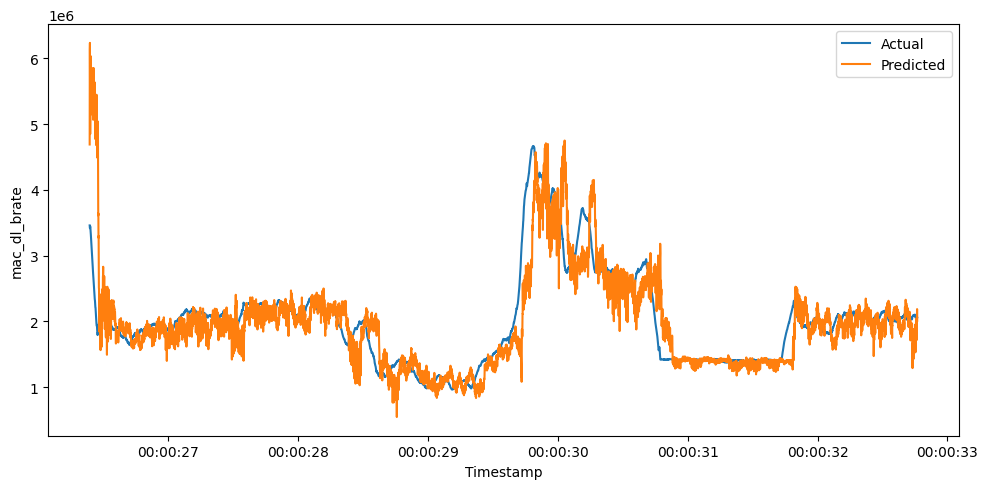

In [10]:
def inverse_transform_univariate_3d(data_3d, scaler):
    n_samples, horizon, n_channels = data_3d.shape
    data_2d = data_3d.reshape(-1, 1)
    data_inv = scaler.inverse_transform(data_2d)
    return data_inv.reshape(n_samples, horizon, 1)

y_test_original = inverse_transform_univariate_3d(y_test_uni, scaler_target)
y_pred_original = inverse_transform_univariate_3d(y_pred_scaled, scaler_target)

# average each forecast window
actual_window_avg = y_test_original[:, :, 0].mean(axis=1)
pred_window_avg = y_pred_original[:, :, 0].mean(axis=1)

# midpoint timestamp of each prediction window
window_time = [ts[len(ts)//2] for ts in test_dates]
window_time = pd.to_datetime(window_time)

plt.figure(figsize=(10, 5))
plt.plot(window_time, actual_window_avg, label='Actual')
plt.plot(window_time, pred_window_avg, label='Predicted')

plt.xlabel('Timestamp')
plt.ylabel(f'{target}')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
results_dir = Path("../results/metrics/youtube_static")
results_dir.mkdir(parents=True, exist_ok=True)

metrics_df = pd.DataFrame([{
    "model": "PatchTST",
    "setting": "univariate",
    "dataset": "youtube_static",
    "rmse": rmse_scaled,
    "mae": mae_scaled,
}])

metrics_file = results_dir / "patch_uni_metrics.csv"
metrics_df.to_csv(metrics_file, index=False)

print("Saved metrics to:", metrics_file)

Saved metrics to: ..\results\metrics\youtube_static\patch_uni_metrics.csv
